In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data=pd.read_csv('data_sets/ecommerce_user_behavior_8000.csv')

In [3]:
data.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


In [4]:
data.isna().sum()

user_id               160
age                   160
gender                160
device_type           160
time_on_site          160
pages_viewed          160
previous_purchases    160
cart_items            160
discount_seen         160
ad_clicked            160
returning_user        160
avg_session_time      160
bounce_rate           160
purchase              160
dtype: int64

In [5]:
# Drop all rows where ALL values are null
data = data.dropna()

In [6]:
# affter removing the null values
print(data.isnull().sum())

user_id               0
age                   0
gender                0
device_type           0
time_on_site          0
pages_viewed          0
previous_purchases    0
cart_items            0
discount_seen         0
ad_clicked            0
returning_user        0
avg_session_time      0
bounce_rate           0
purchase              0
dtype: int64


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6019 entries, 1 to 7999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             6019 non-null   float64
 1   age                 6019 non-null   float64
 2   gender              6019 non-null   object 
 3   device_type         6019 non-null   object 
 4   time_on_site        6019 non-null   float64
 5   pages_viewed        6019 non-null   float64
 6   previous_purchases  6019 non-null   float64
 7   cart_items          6019 non-null   float64
 8   discount_seen       6019 non-null   float64
 9   ad_clicked          6019 non-null   float64
 10  returning_user      6019 non-null   float64
 11  avg_session_time    6019 non-null   float64
 12  bounce_rate         6019 non-null   float64
 13  purchase            6019 non-null   float64
dtypes: float64(12), object(2)
memory usage: 705.4+ KB


In [8]:
data.columns

Index(['user_id', 'age', 'gender', 'device_type', 'time_on_site',
       'pages_viewed', 'previous_purchases', 'cart_items', 'discount_seen',
       'ad_clicked', 'returning_user', 'avg_session_time', 'bounce_rate',
       'purchase'],
      dtype='object')

# handling outliers

In [9]:
data['device_type'].value_counts()

device_type
Mobile     3610
Desktop    1811
Tablet      598
Name: count, dtype: int64

In [10]:
data['device_type'].value_counts()

device_type
Mobile     3610
Desktop    1811
Tablet      598
Name: count, dtype: int64

In [11]:
data['time_on_site'].value_counts()

time_on_site
28.74    8
5.03     8
12.21    8
18.67    8
8.56     7
        ..
23.00    1
8.09     1
7.71     1
29.62    1
18.20    1
Name: count, Length: 2572, dtype: int64

In [12]:
data['avg_session_time'].value_counts()

avg_session_time
2.87     8
13.13    8
9.56     7
16.00    7
13.73    7
        ..
18.92    1
23.90    1
34.90    1
5.23     1
38.85    1
Name: count, Length: 2898, dtype: int64

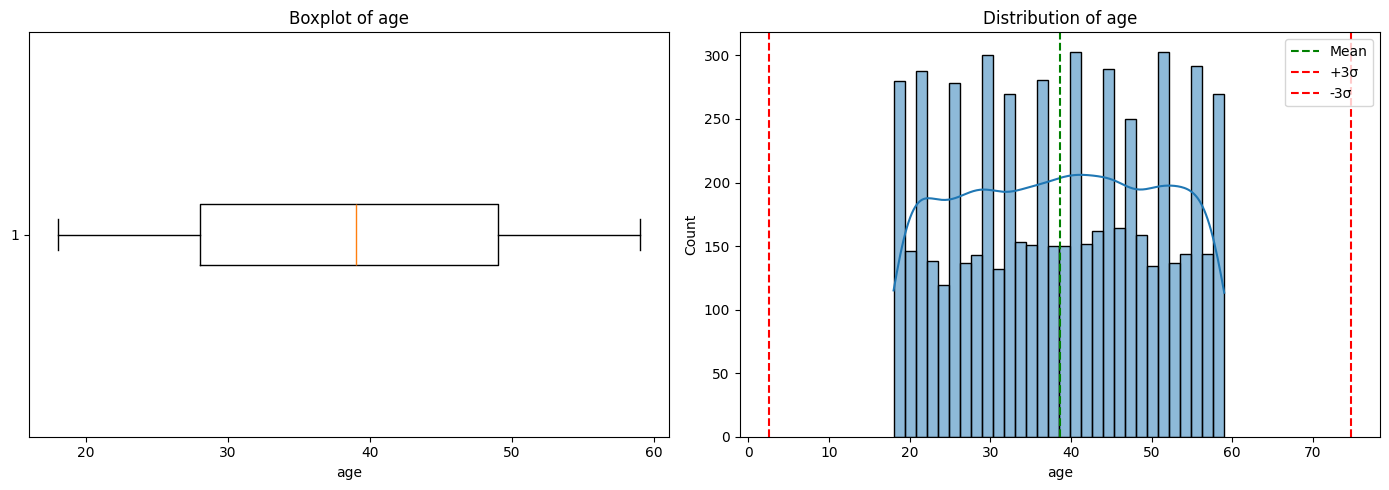

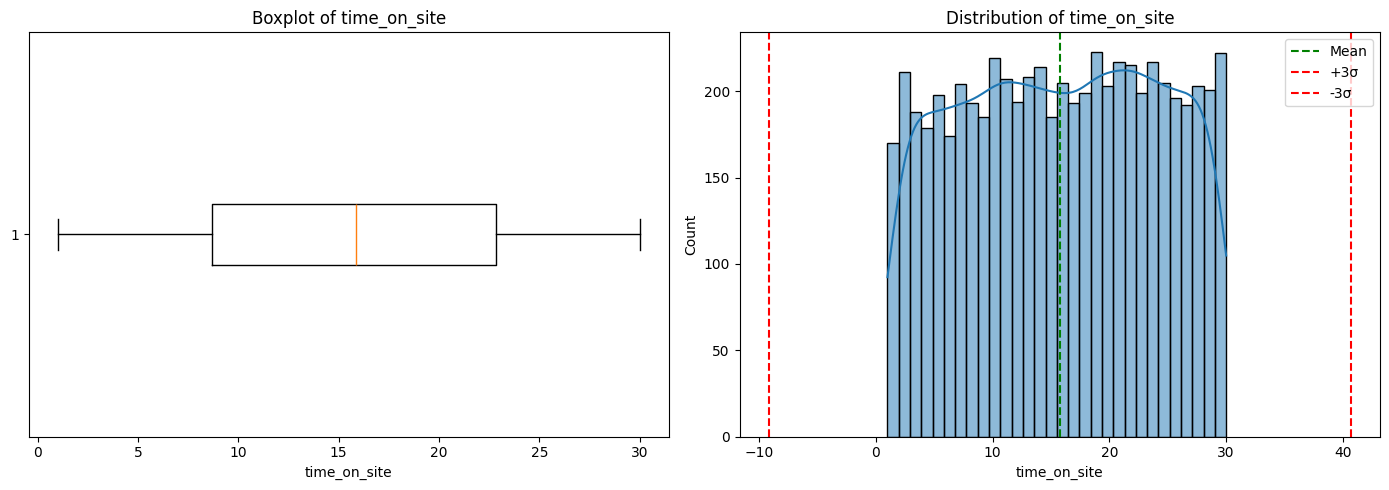

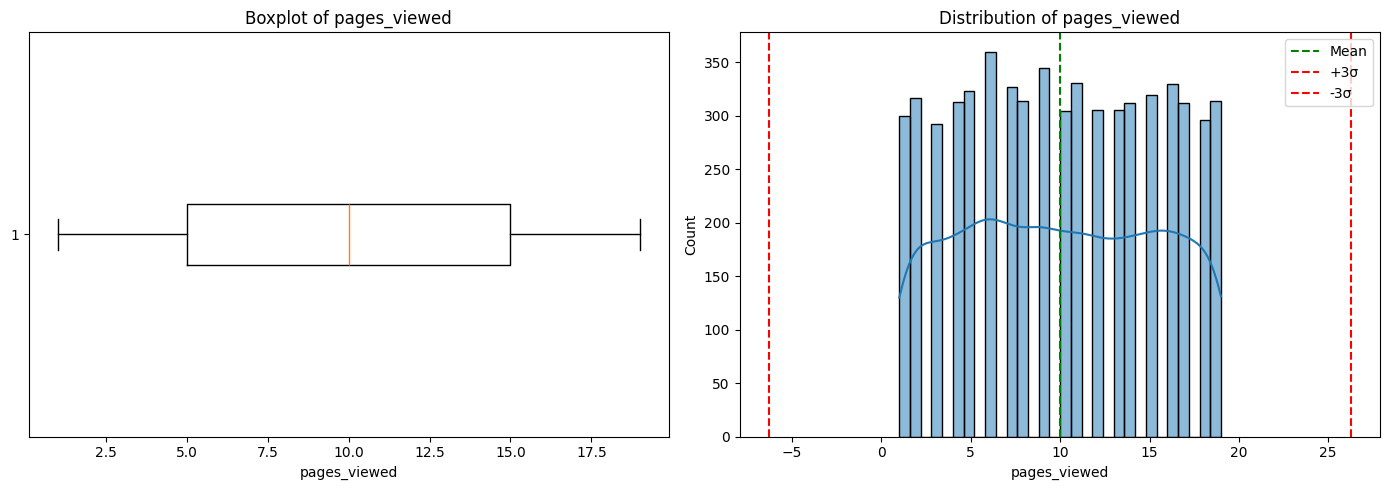

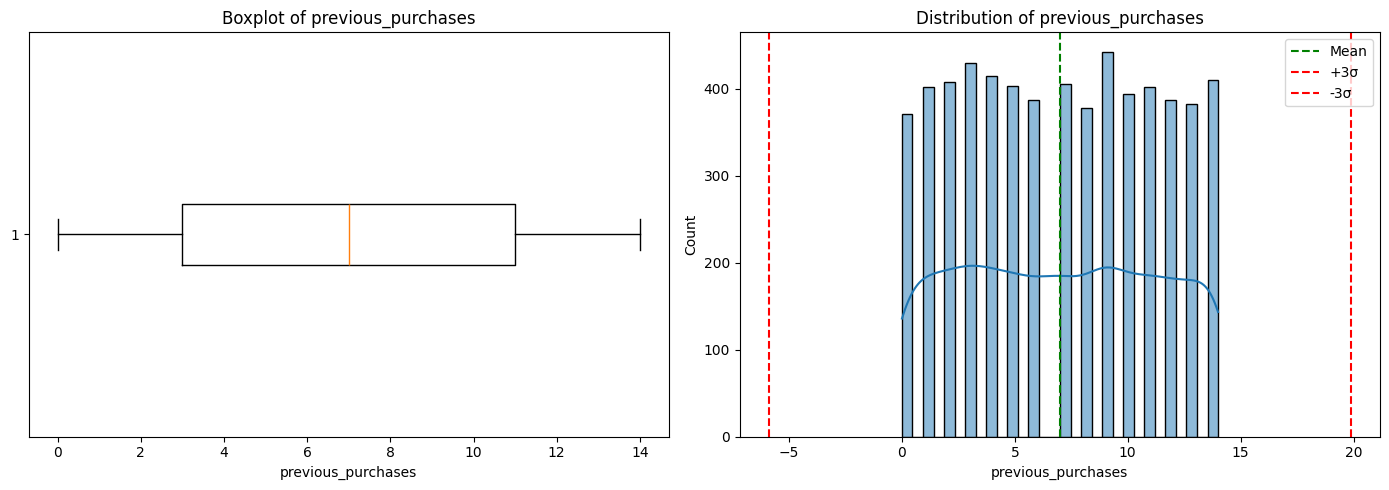

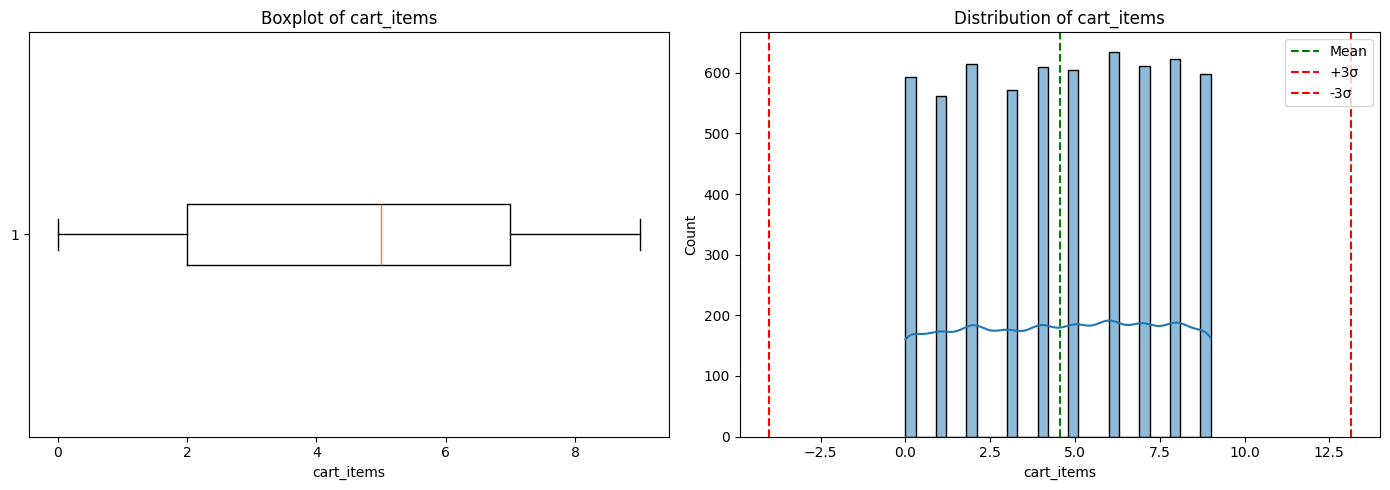

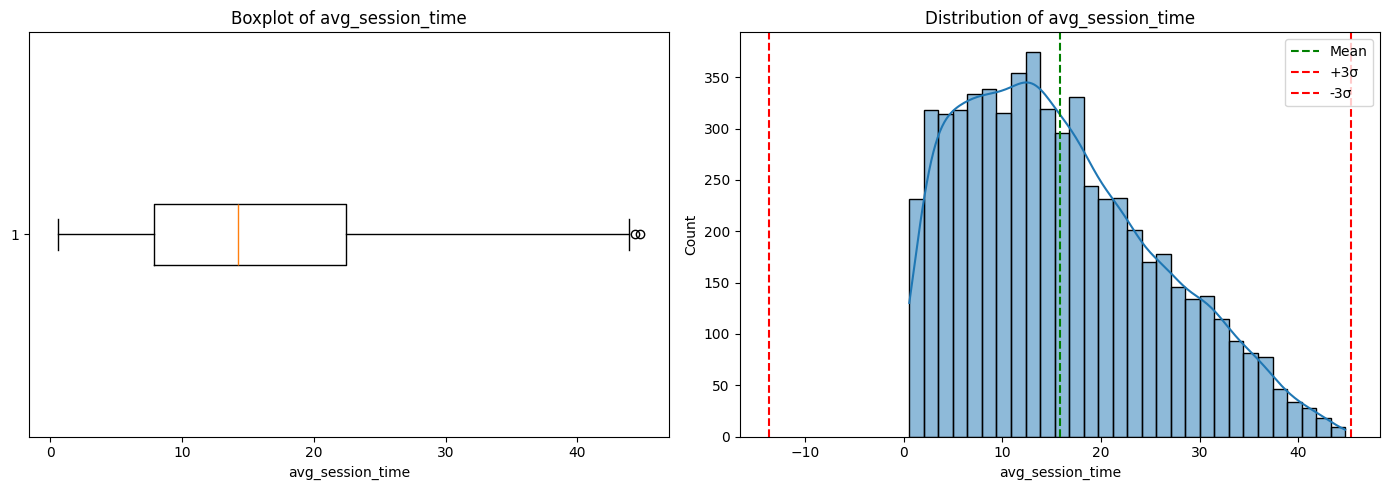

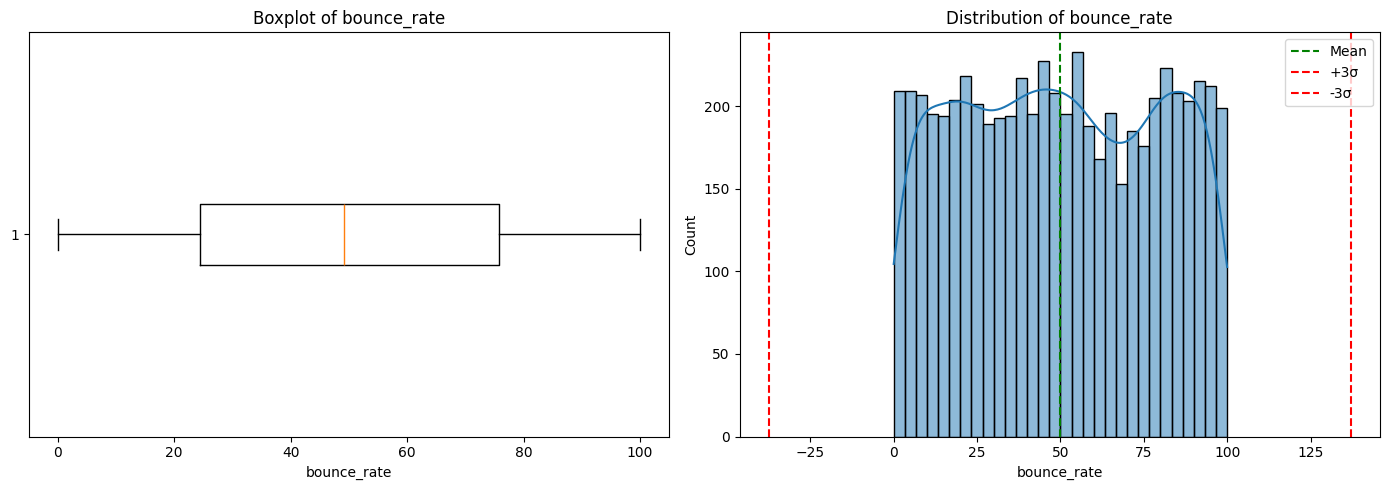

In [13]:
def getOutlers(data,cols):
    for col in cols:
        mean = data[col].mean()
        std = data[col].std()
        
        plt.figure(figsize=(14,5))

        # Boxplot
        plt.subplot(1,2,1)
        plt.boxplot(data[col],vert=False)
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)

        # histogram with KDE
        plt.subplot(1,2,2)
        sns.histplot(data=data,x=col,kde=True , bins=30)
        plt.axvline(mean,color='green',linestyle='--',label='Mean')
        plt.axvline(mean + 3*std, color='red',linestyle='--',label='+3σ')
        plt.axvline(mean - 3*std, color='red', linestyle='--', label='-3σ')
        plt.title(f"Distribution of {col}")
        plt.legend()

        plt.tight_layout()
        plt.show()
cols = [
    'age', 'time_on_site', 'pages_viewed', 
    'previous_purchases', 'cart_items', 
    'avg_session_time', 'bounce_rate']
getOutlers(data,cols)

In [14]:
upper = data['avg_session_time'].quantile(0.99)
lower = data['avg_session_time'].quantile(0.01)

data['avg_session_time'] = data['avg_session_time'].clip(lower, upper)

In [15]:
data['purchase'].value_counts()

purchase
1.0    6008
0.0      11
Name: count, dtype: int64

In [16]:
data.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,6.0,56.0,Female,Desktop,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0
6,7.0,36.0,Male,Mobile,7.60,11.0,11.0,6.0,1.0,1.0,1.0,4.51,13.12,1.0
7,8.0,40.0,Female,Mobile,26.98,7.0,5.0,2.0,1.0,0.0,0.0,33.34,12.61,1.0


## Feature enginerring

In [17]:
 ## Data encoding

In [18]:
data['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [19]:
data['gender']=data['gender'].replace({'Male':0,'Female':1})

C:\Users\ganes\AppData\Local\Temp\ipykernel_29004\3507592353.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['gender']=data['gender'].replace({'Male':0,'Female':1})


In [20]:
# device_type column encode

In [21]:
data['device_type'].unique()

array(['Mobile', 'Desktop', 'Tablet'], dtype=object)

In [22]:
data['device_type']=data['device_type'].replace({'Mobile':0,'Desktop':1,'Tablet':2})

C:\Users\ganes\AppData\Local\Temp\ipykernel_29004\3765390587.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['device_type']=data['device_type'].replace({'Mobile':0,'Desktop':1,'Tablet':2})


In [23]:
data.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
1,2.0,46.0,0,0,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
4,5.0,38.0,1,0,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,6.0,56.0,1,1,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0
6,7.0,36.0,0,0,7.60,11.0,11.0,6.0,1.0,1.0,1.0,4.51,13.12,1.0
7,8.0,40.0,1,0,26.98,7.0,5.0,2.0,1.0,0.0,0.0,33.34,12.61,1.0


# heatmap for correlation

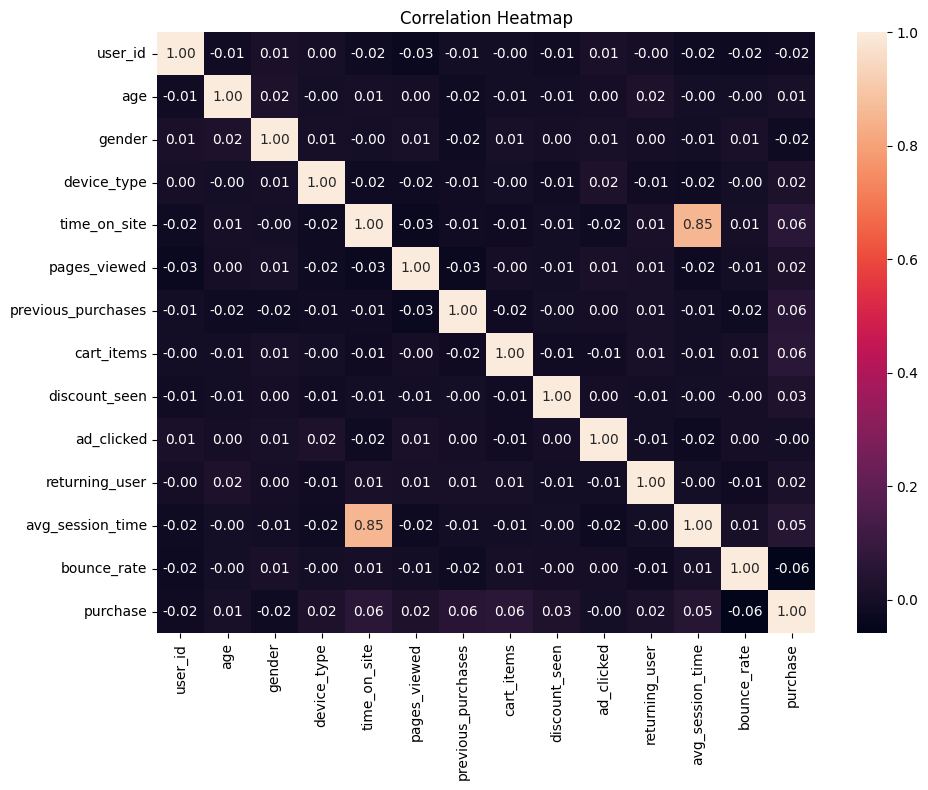

In [24]:
# Pehle figure size set karo, phir heatmap banao
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [25]:
data.describe()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
count,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.00000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000
mean,4017.589965,38.610567,0.500748,0.499585,15.757822,9.981725,6.991693,4.55358,0.502243,0.502741,0.506895,15.811882,49.812866,0.998172
std,2309.293701,12.031552,0.500041,0.669909,8.306630,5.428621,4.297541,2.86118,0.500037,0.500034,0.499994,9.785075,29.091049,0.042714
min,2.000000,18.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.141800,0.010000,0.000000
25%,2031.000000,28.000000,0.000000,0.000000,8.670000,5.000000,3.000000,2.00000,0.000000,0.000000,0.000000,7.870000,24.510000,1.000000
50%,4020.000000,39.000000,1.000000,0.000000,15.840000,10.000000,7.000000,5.00000,1.000000,1.000000,1.000000,14.290000,49.210000,1.000000
75%,6021.500000,49.000000,1.000000,1.000000,22.840000,15.000000,11.000000,7.00000,1.000000,1.000000,1.000000,22.415000,75.820000,1.000000
max,8000.000000,59.000000,1.000000,2.000000,30.000000,19.000000,14.000000,9.00000,1.000000,1.000000,1.000000,40.128200,99.970000,1.000000


In [26]:
# data is imbalnced so that why i do SMOTE techinque
# Data is imbalanced so that why i do SMOTE TECHNIQUE
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Step 1 - X aur y define karo
X = data.drop(['user_id', 'purchase'], axis=1)
y = data['purchase']

# Step 2 - Pehle split karo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Step 3 - Sirf train data pe SMOTE lagao
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Check karo
print("Before SMOTE:")
print(pd.Series(y).value_counts())

print("\nAfter SMOTE (Train only):")
print(pd.Series(y_train).value_counts())

print("\nTest data (Real data - no SMOTE):")
print(pd.Series(y_test).value_counts())

Before SMOTE:
purchase
1.0    6008
0.0      11
Name: count, dtype: int64

After SMOTE (Train only):
purchase
1.0    4207
0.0    4207
Name: count, dtype: int64

Test data (Real data - no SMOTE):
purchase
1.0    1801
0.0       5
Name: count, dtype: int64


## KNN

In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [28]:
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [29]:
test_pred = knn.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,test_pred)

0.9955703211517165

In [31]:
train_pred=knn.predict(X_train)

In [32]:
accuracy_score(y_train,train_pred)

0.9982172569526979

In [33]:
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
parameters = {'n_neighbors' : np.arange(3,16,2),
              'metric':['euclidean','cosine','manhattan','minkowski']}
gcv = GridSearchCV(estimator=knn,param_grid=parameters)
result = gcv.fit(X_train,y_train)

In [34]:
result

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'cosine', ...], 'n_neighbors': array([ 3, 5..., 11, 13, 15])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [35]:
gcv.best_params_g

{'metric': 'euclidean', 'n_neighbors': np.int64(3)}

In [36]:
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

In [37]:
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [38]:
test_pred=knn.predict(X_test)

In [39]:
accuracy_score(y_test,test_pred)

0.9950166112956811

In [40]:
train_pred=knn.predict(X_train)

In [41]:
accuracy_score(y_train,train_pred)

0.9992869027810791

In [42]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,test_pred))
confusion_matrix(y_test,test_pred)

              precision    recall  f1-score   support

         0.0       0.25      0.40      0.31         5
         1.0       1.00      1.00      1.00      1801

    accuracy                           1.00      1806
   macro avg       0.62      0.70      0.65      1806
weighted avg       1.00      1.00      1.00      1806



array([[   2,    3],
       [   6, 1795]])

In [43]:
## DECISION TREE ALGORITHM

In [44]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

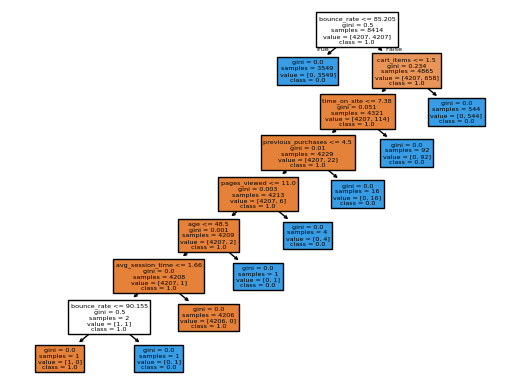

In [45]:
from sklearn.tree import plot_tree
plot_tree(dt,filled=True,feature_names=X.columns,class_names=[str(i) for i in y.unique()])
plt.show()

In [46]:
data.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
1,2.0,46.0,0,0,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
4,5.0,38.0,1,0,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,6.0,56.0,1,1,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0
6,7.0,36.0,0,0,7.60,11.0,11.0,6.0,1.0,1.0,1.0,4.51,13.12,1.0
7,8.0,40.0,1,0,26.98,7.0,5.0,2.0,1.0,0.0,0.0,33.34,12.61,1.0


In [47]:
test_pred = dt.predict(X_test)
train_pred = dt.predict(X_train)

In [48]:
accuracy_score(y_test,test_pred)

0.9977851605758582

In [49]:
accuracy_score(y_train,train_pred)

1.0

In [50]:
# Hyperparameter tuning to fix overfitting

In [51]:
dt = DecisionTreeClassifier()
parameters = {'criterion':['entropy','gini']}
gcv = GridSearchCV(estimator=dt,param_grid=parameters)
result = gcv.fit(X_train,y_train)

In [52]:
gcv.best_params_

{'criterion': 'entropy'}

In [53]:
dt = DecisionTreeClassifier(criterion='entropy')
dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [54]:
test_pred = dt.predict(X_test)
train_pred = dt.predict(X_train)

In [55]:
accuracy_score(y_test,test_pred)

0.9977851605758582

In [56]:
accuracy_score(y_train,train_pred)

1.0

## Random Forest Algorithm


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
rf=RandomForestClassifier()
result= cross_validate(rf,X_train,y_train)
rf.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [58]:
accuracy_score(y_test,test_pred)

0.9977851605758582

In [59]:
train_pred=rf.predict(X_train)

In [60]:
accuracy_score(y_train,train_pred)

1.0

In [61]:
result

{'fit_time': array([1.34168148, 1.42037058, 1.54179668, 1.38823128, 1.49677873]),
 'score_time': array([0.03501987, 0.03361869, 0.03821397, 0.03734803, 0.04121161]),
 'test_score': array([0.99821747, 1.        , 1.        , 1.        , 1.        ])}

In [62]:
result['test_score'].mean()

np.float64(0.9996434937611408)

In [63]:
rf = RandomForestClassifier()
parameters = {'n_estimators':[100,200]}
gcv = GridSearchCV(rf,param_grid=parameters)
result = gcv.fit(X_train,y_train)

In [64]:
gcv.best_params_

{'n_estimators': 200}

In [65]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [66]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

In [67]:
accuracy_score(y_test,test_pred)

0.9977851605758582

In [68]:
accuracy_score(y_train,train_pred)

1.0

In [69]:
# max_depth add karo - overfitting fix hoga
rf = RandomForestClassifier()
parameters = {'n_estimators': [100, 200],
              'max_depth': [5, 10, 15]}
gcv = GridSearchCV(rf, param_grid=parameters)
gcv.fit(X_train, y_train)

print("Best Params:", gcv.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 200}


In [70]:
rf = RandomForestClassifier(
    n_estimators=gcv.best_params_['n_estimators'],
    max_depth=gcv.best_params_['max_depth']
)
rf.fit(X_train, y_train)

test_pred = rf.predict(X_test)   # Add this line!
train_pred = rf.predict(X_train)

print("Test Accuracy :", accuracy_score(y_test, test_pred))
print("Train Accuracy:", accuracy_score(y_train, train_pred))

Test Accuracy : 0.9977851605758582
Train Accuracy: 1.0


In [71]:
print(classification_report(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.20      0.33         5
         1.0       1.00      1.00      1.00      1801

    accuracy                           1.00      1806
   macro avg       1.00      0.60      0.67      1806
weighted avg       1.00      1.00      1.00      1806

[[   1    4]
 [   0 1801]]


## LOGISTIC REGRESSION

In [72]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [73]:
test_pred=lr.predict(X_test)

In [74]:
accuracy_score(y_test,test_pred)

0.9994462901439646

In [75]:
train_pred=lr.predict(X_train)

In [76]:
accuracy_score(y_train,train_pred)

0.9992869027810791

In [77]:
probability = lr.predict_proba(X_test)

In [78]:
probability

array([[0.00000000e+00, 1.00000000e+00],
       [3.01980663e-13, 1.00000000e+00],
       [1.43060008e-10, 1.00000000e+00],
       ...,
       [0.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 1.00000000e+00]], shape=(1806, 2))

In [79]:
probability[0]

array([0., 1.])

In [80]:
test_pred[0]

np.float64(1.0)

In [81]:
y_test.iloc[0]

np.float64(1.0)

In [82]:
## suport vector machine

In [83]:
data.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
1,2.0,46.0,0,0,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
4,5.0,38.0,1,0,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,6.0,56.0,1,1,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0
6,7.0,36.0,0,0,7.60,11.0,11.0,6.0,1.0,1.0,1.0,4.51,13.12,1.0
7,8.0,40.0,1,0,26.98,7.0,5.0,2.0,1.0,0.0,0.0,33.34,12.61,1.0


# SVM

In [84]:
from sklearn.svm import SVC
model=SVC()
model.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [85]:
test_pred=model.predict(X_test)

In [86]:
train_pred = model.predict(X_train)

In [87]:
accuracy_score(y_test,test_pred)

0.9905869324473976

In [88]:
accuracy_score(y_train,train_pred)

0.9948894699310673

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

gcv = GridSearchCV(pipe, {
    'svc__kernel': ['linear','poly','rbf']
})
result = gcv.fit(X_train,y_train)

In [90]:
gcv.best_params_

{'svc__kernel': 'linear'}

In [91]:
model = SVC()
model.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [92]:
test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

In [93]:
accuracy_score(y_test,test_pred)

0.9905869324473976

In [94]:
accuracy_score(y_train,train_pred)

0.9948894699310673

In [95]:
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
model.fit(X_train, y_train)  # SVM

from sklearn.metrics import accuracy_score
import pandas as pd

results = []

# KNN
knn_train = accuracy_score(y_train, knn.predict(X_train))
knn_test = accuracy_score(y_test, knn.predict(X_test))
results.append(["KNN", knn_train, knn_test])

# Decision Tree
dt_train = accuracy_score(y_train, dt.predict(X_train))
dt_test = accuracy_score(y_test, dt.predict(X_test))
results.append(["Decision Tree", dt_train, dt_test])

# Random Forest
rf_train = accuracy_score(y_train, rf.predict(X_train))
rf_test = accuracy_score(y_test, rf.predict(X_test))
results.append(["Random Forest", rf_train, rf_test])

# Logistic Regression
lr_train = accuracy_score(y_train, lr.predict(X_train))
lr_test = accuracy_score(y_test, lr.predict(X_test))
results.append(["Logistic Regression", lr_train, lr_test])

# SVM
svm_train = accuracy_score(y_train, model.predict(X_train))
svm_test = accuracy_score(y_test, model.predict(X_test))
results.append(["SVM", svm_train, svm_test])

accuracy_table = pd.DataFrame(
    results,
    columns=["Model", "Training Accuracy", "Testing Accuracy"]
)
accuracy_table.round(3)

,Model,Training Accuracy,Testing Accuracy
0,KNN,0.999,0.995
1,Decision Tree,1.000,0.998
2,Random Forest,1.000,0.998
3,Logistic Regression,0.999,0.999
4,SVM,0.995,0.991


In [96]:
accuracy_table["Training Accuracy"]*=100
accuracy_table["Testing Accuracy"] *=100
accuracy_table.round(2)

,Model,Training Accuracy,Testing Accuracy
0,KNN,99.93,99.50
1,Decision Tree,100.00,99.78
2,Random Forest,100.00,99.78
3,Logistic Regression,99.93,99.94
4,SVM,99.49,99.06


In [97]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
    "KNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Logistic Regression": lr,
    "SVM": model
}

for name, m in models.items():
    print(f"\n{name} Model")
    y_pred = m.predict(X_test)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))


KNN Model
Confusion Matrix:
[[   2    3]
 [   6 1795]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.25      0.40      0.31         5
         1.0       1.00      1.00      1.00      1801

    accuracy                           1.00      1806
   macro avg       0.62      0.70      0.65      1806
weighted avg       1.00      1.00      1.00      1806


Decision Tree Model
Confusion Matrix:
[[   1    4]
 [   0 1801]]
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.20      0.33         5
         1.0       1.00      1.00      1.00      1801

    accuracy                           1.00      1806
   macro avg       1.00      0.60      0.67      1806
weighted avg       1.00      1.00      1.00      1806


Random Forest Model
Confusion Matrix:
[[   1    4]
 [   0 1801]]
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.20 

In [98]:
import pickle

In [99]:
with open('model.pkl','wb') as f:
    pickle.dump(rf,f)
    print("Model Save")

Model Save
